In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [3]:
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]

# Final validated channel map
FINAL_CHANNEL_MAP = {
    "EmotiBit_1": {"selected_channel": "PPG_1", "backup_channel": "PPG_2"},
    "EmotiBit_2": {"selected_channel": "PPG_1", "backup_channel": "PPG_3"},
    "EmotiBit_3": {"selected_channel": "PPG_1", "backup_channel": "PPG_3"},
    "EmotiBit_4": {"selected_channel": "PPG_2", "backup_channel": "PPG_1"},
    "EmotiBit_5": {"selected_channel": "PPG_1", "backup_channel": "PPG_2"},
    "EmotiBit_6": {"selected_channel": "PPG_2", "backup_channel": "PPG_3"},
    "EmotiBit_7": {"selected_channel": "PPG_1", "backup_channel": "PPG_2"},
}

LOWCUT_HZ = 0.5
HIGHCUT_HZ = 5.0
FILTER_ORDER = 3
ROBUST_Z_CLIP = 8.0

In [6]:
final_map_rows = []
for emotibit_id, info in FINAL_CHANNEL_MAP.items():
    final_map_rows.append({
        "emotibit_id": emotibit_id,
        "selected_channel": info["selected_channel"],
        "backup_channel": info["backup_channel"],
    })

final_map_df = pd.DataFrame(final_map_rows).sort_values("emotibit_id").reset_index(drop=True)
display(final_map_df)

out_path = TABLES_DIR / "ppg_final_channel_map_used_for_preparation.csv"
final_map_df.to_csv(out_path, index=False)
print("Saved:", out_path)

,emotibit_id,selected_channel,backup_channel
0,EmotiBit_1,PPG_1,PPG_2
1,EmotiBit_2,PPG_1,PPG_3
2,EmotiBit_3,PPG_1,PPG_3
3,EmotiBit_4,PPG_2,PPG_1
4,EmotiBit_5,PPG_1,PPG_2
5,EmotiBit_6,PPG_2,PPG_3
6,EmotiBit_7,PPG_1,PPG_2


Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_final_channel_map_used_for_preparation.csv


In [7]:
def load_segment_csv(emotibit_id, segment):
    path = PROCESSED_DIR / f"{emotibit_id}_{segment}.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def estimate_fs_from_timestamps(timestamps):
    timestamps = np.asarray(timestamps, dtype=float)
    if len(timestamps) < 2:
        return np.nan
    diffs = np.diff(timestamps)
    diffs = diffs[np.isfinite(diffs)]
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return np.nan
    return 1.0 / np.median(diffs)


def robust_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return np.full_like(x, np.nan, dtype=float)
    return 0.6745 * (x - med) / mad


def clip_extreme_outliers(x, z_thresh=8.0):
    x = np.asarray(x, dtype=float).copy()
    z = robust_zscore(x)

    if np.all(np.isnan(z)):
        return x, 0

    valid = np.isfinite(z)
    if not np.any(valid):
        return x, 0

    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return x, 0

    delta = (z_thresh * mad) / 0.6745
    lower = med - delta
    upper = med + delta

    before = x.copy()
    x = np.clip(x, lower, upper)
    n_clipped = int(np.sum(before != x))
    return x, n_clipped


def detrend_signal(x):
    return signal.detrend(np.asarray(x, dtype=float), type="linear")


def butter_bandpass_filter(x, fs, lowcut, highcut, order=3):
    x = np.asarray(x, dtype=float)

    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    if not (0 < low < high < 1):
        raise ValueError(f"Invalid bandpass settings: fs={fs}, lowcut={lowcut}, highcut={highcut}")

    b, a = signal.butter(order, [low, high], btype="bandpass")
    y = signal.filtfilt(b, a, x)
    return y


def normalize_signal(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return x - mu
    return (x - mu) / sd

In [8]:
prep_rows = []

for emotibit_id, info in FINAL_CHANNEL_MAP.items():
    selected_channel = info["selected_channel"]
    backup_channel = info["backup_channel"]

    for segment_name in SEGMENTS:
        df, path = load_segment_csv(emotibit_id, segment_name)

        if df is None:
            print("Missing:", path)
            continue

        if selected_channel not in df.columns:
            print(f"{selected_channel} missing in {path.name}")
            continue

        timestamps = df["timestamp"].values.astype(float)
        time_rel = df["time_from_segment_start_sec"].values.astype(float)
        raw = df[selected_channel].values.astype(float)

        fs = estimate_fs_from_timestamps(timestamps)
        if not np.isfinite(fs):
            print(f"Could not estimate fs for {emotibit_id} {segment_name}")
            continue

        clipped, n_clipped = clip_extreme_outliers(raw, z_thresh=ROBUST_Z_CLIP)
        detrended = detrend_signal(clipped)
        filtered = butter_bandpass_filter(
            detrended,
            fs=fs,
            lowcut=LOWCUT_HZ,
            highcut=HIGHCUT_HZ,
            order=FILTER_ORDER
        )
        filtered_z = normalize_signal(filtered)

        out_df = pd.DataFrame({
            "timestamp": timestamps,
            "time_from_segment_start_sec": time_rel,
            "selected_channel_name": selected_channel,
            "backup_channel_name": backup_channel,
            "selected_channel_raw": raw,
            "selected_channel_clipped": clipped,
            "selected_channel_detrended": detrended,
            "selected_channel_filtered": filtered,
            "selected_channel_filtered_z": filtered_z,
        })

        out_path = PROCESSED_DIR / f"{emotibit_id}_{segment_name}_prepared.csv"
        out_df.to_csv(out_path, index=False)

        prep_rows.append({
            "emotibit_id": emotibit_id,
            "segment": segment_name,
            "selected_channel": selected_channel,
            "backup_channel": backup_channel,
            "fs_estimated": fs,
            "n_samples": len(out_df),
            "n_clipped_samples": n_clipped,
            "raw_std": float(np.nanstd(raw)),
            "filtered_std": float(np.nanstd(filtered)),
            "output_csv": out_path.name,
        })

        print("Saved:", out_path)

preparation_summary = pd.DataFrame(prep_rows).sort_values(
    ["emotibit_id", "segment"]
).reset_index(drop=True)

display(preparation_summary)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_pre_meditation_prepared.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_main_meditation_prepared.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_recovery_prepared.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_pre_meditation_prepared.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_main_meditation_prepared.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_recovery_prepared.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_3_pre_meditation_prepared.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_3_main_meditation_prepared.csv
Saved: /Users/sabirthapa/

,emotibit_id,segment,selected_channel,backup_channel,fs_estimated,n_samples,n_clipped_samples,raw_std,filtered_std,output_csv
0,EmotiBit_1,main_meditation,PPG_1,PPG_2,99.496057,74968,0,669.902309,29.888527,EmotiBit_1_main_meditation_prepared.csv
1,EmotiBit_1,pre_meditation,PPG_1,PPG_2,99.496057,24288,156,358.820865,22.631662,EmotiBit_1_pre_meditation_prepared.csv
2,EmotiBit_1,recovery,PPG_1,PPG_2,99.496057,9430,761,311.895650,20.357690,EmotiBit_1_recovery_prepared.csv
3,EmotiBit_2,main_meditation,PPG_1,PPG_3,100.020871,75362,0,1199.388913,43.366608,EmotiBit_2_main_meditation_prepared.csv
4,EmotiBit_2,pre_meditation,PPG_1,PPG_3,100.020871,24416,0,146.482052,14.591566,EmotiBit_2_pre_meditation_prepared.csv
5,EmotiBit_2,recovery,PPG_1,PPG_3,100.020871,9480,0,185.453129,60.009726,EmotiBit_2_recovery_prepared.csv
6,EmotiBit_3,main_meditation,PPG_1,PPG_3,98.920147,74534,0,1594.103293,25.742586,EmotiBit_3_main_meditation_prepared.csv
7,EmotiBit_3,pre_meditation,PPG_1,PPG_3,98.920147,24147,0,229.699698,33.215763,EmotiBit_3_pre_meditation_prepared.csv
8,EmotiBit_3,recovery,PPG_1,PPG_3,98.920147,9375,1681,757.386498,45.849539,EmotiBit_3_recovery_prepared.csv
9,EmotiBit_4,main_meditation,PPG_2,PPG_1,99.070049,74646,0,825.733776,21.488920,EmotiBit_4_main_meditation_prepared.csv


In [9]:
out_path = TABLES_DIR / "ppg_preparation_summary.csv"
preparation_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_preparation_summary.csv


In [10]:
display(
    preparation_summary[
        ["emotibit_id", "segment", "selected_channel", "fs_estimated", "n_samples", "n_clipped_samples", "filtered_std"]
    ]
)

,emotibit_id,segment,selected_channel,fs_estimated,n_samples,n_clipped_samples,filtered_std
0,EmotiBit_1,main_meditation,PPG_1,99.496057,74968,0,29.888527
1,EmotiBit_1,pre_meditation,PPG_1,99.496057,24288,156,22.631662
2,EmotiBit_1,recovery,PPG_1,99.496057,9430,761,20.357690
3,EmotiBit_2,main_meditation,PPG_1,100.020871,75362,0,43.366608
4,EmotiBit_2,pre_meditation,PPG_1,100.020871,24416,0,14.591566
5,EmotiBit_2,recovery,PPG_1,100.020871,9480,0,60.009726
6,EmotiBit_3,main_meditation,PPG_1,98.920147,74534,0,25.742586
7,EmotiBit_3,pre_meditation,PPG_1,98.920147,24147,0,33.215763
8,EmotiBit_3,recovery,PPG_1,98.920147,9375,1681,45.849539
9,EmotiBit_4,main_meditation,PPG_2,99.070049,74646,0,21.488920


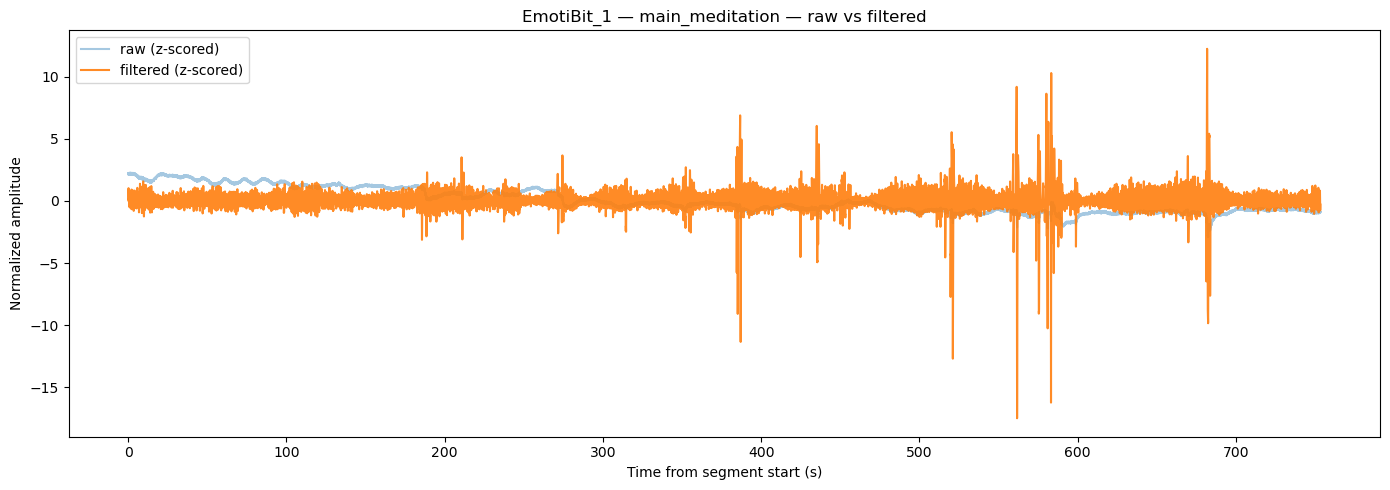

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_raw_vs_filtered.png


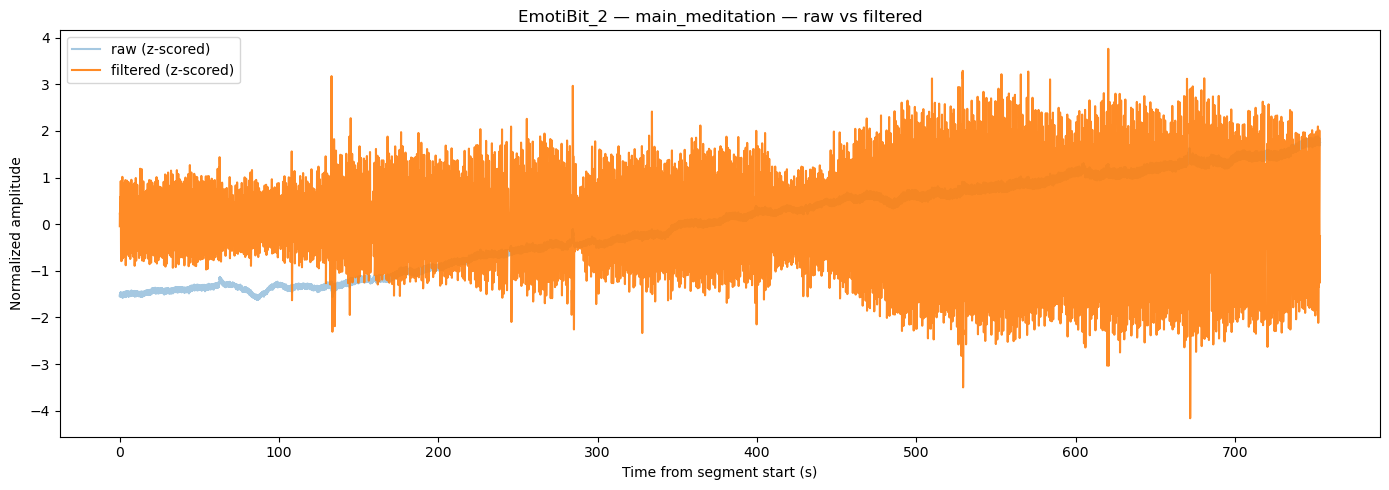

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_raw_vs_filtered.png


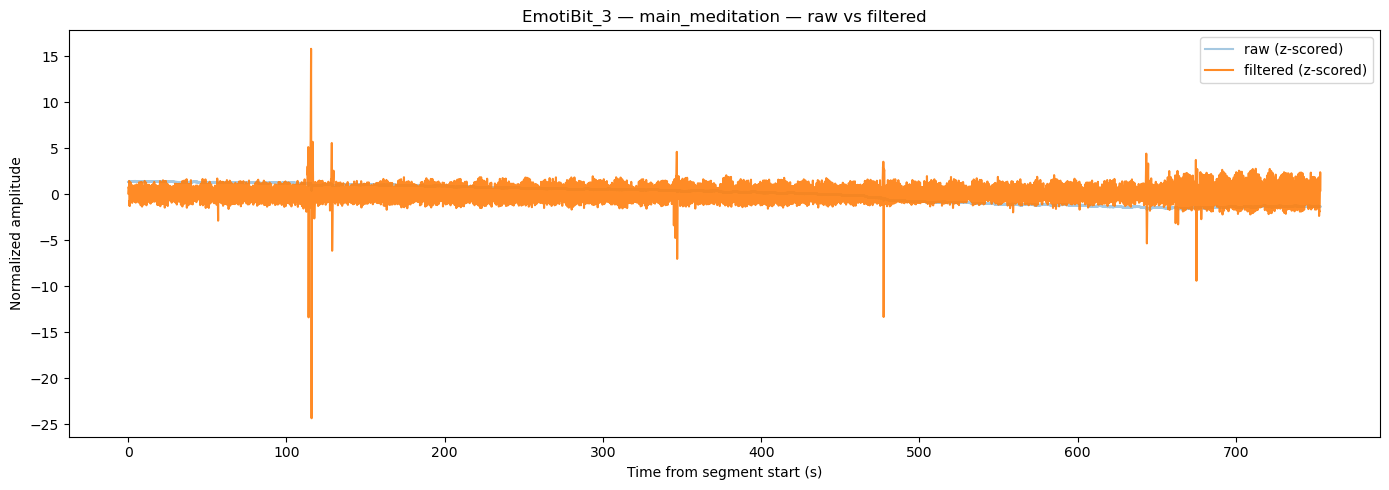

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_raw_vs_filtered.png


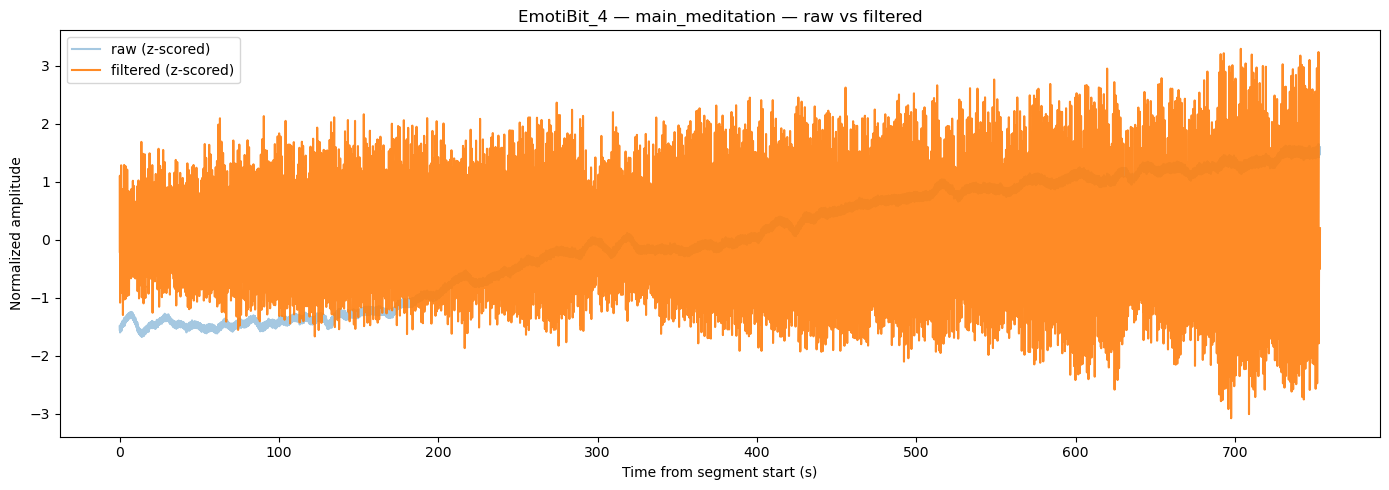

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_raw_vs_filtered.png


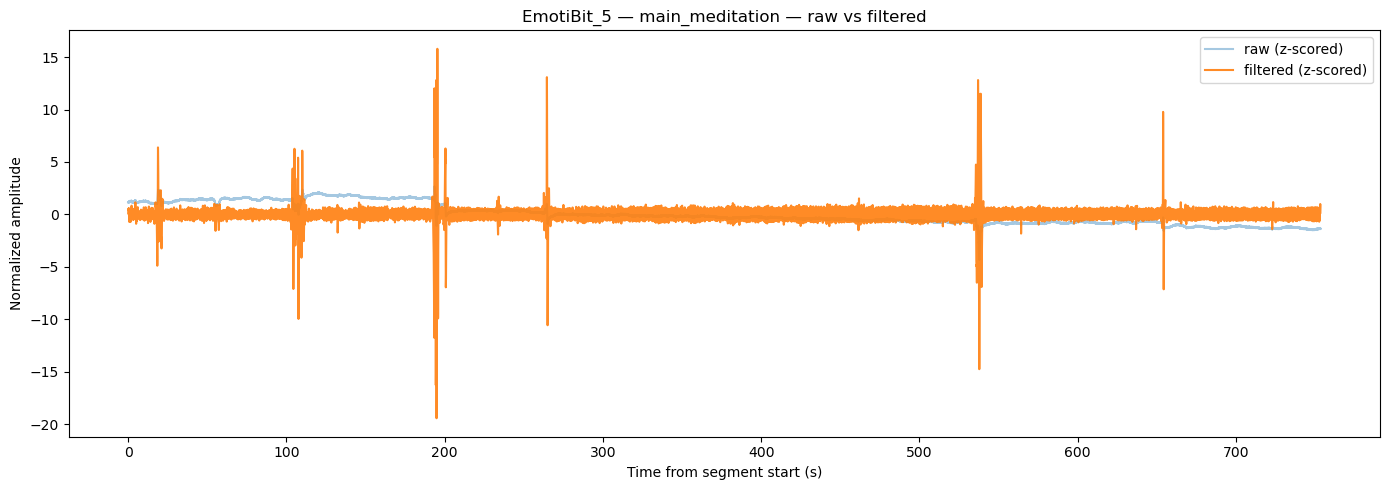

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_5_main_meditation_raw_vs_filtered.png


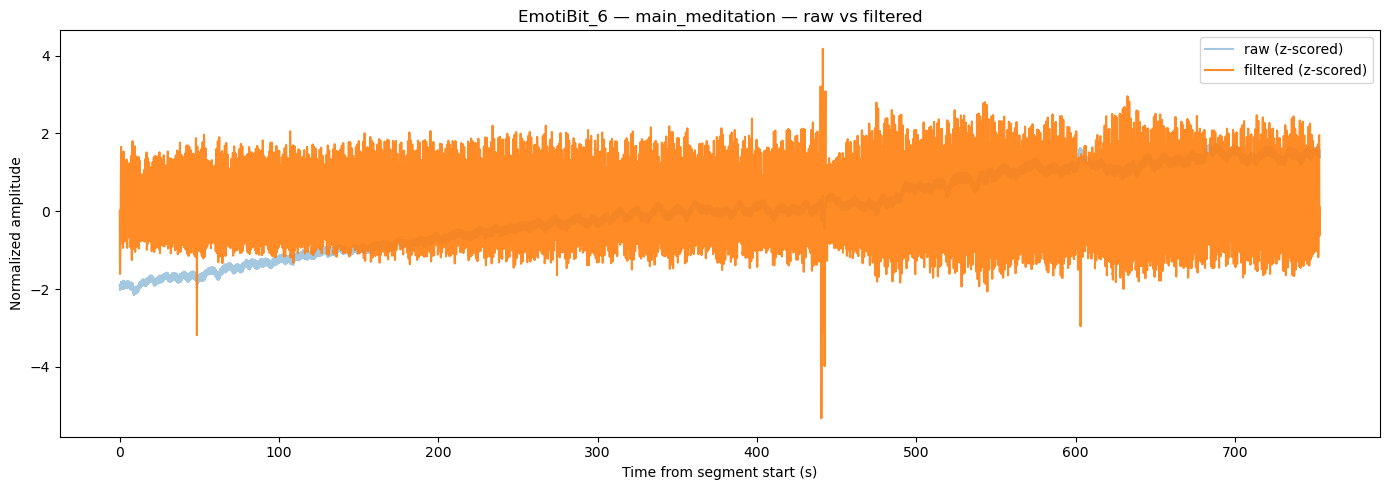

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_raw_vs_filtered.png


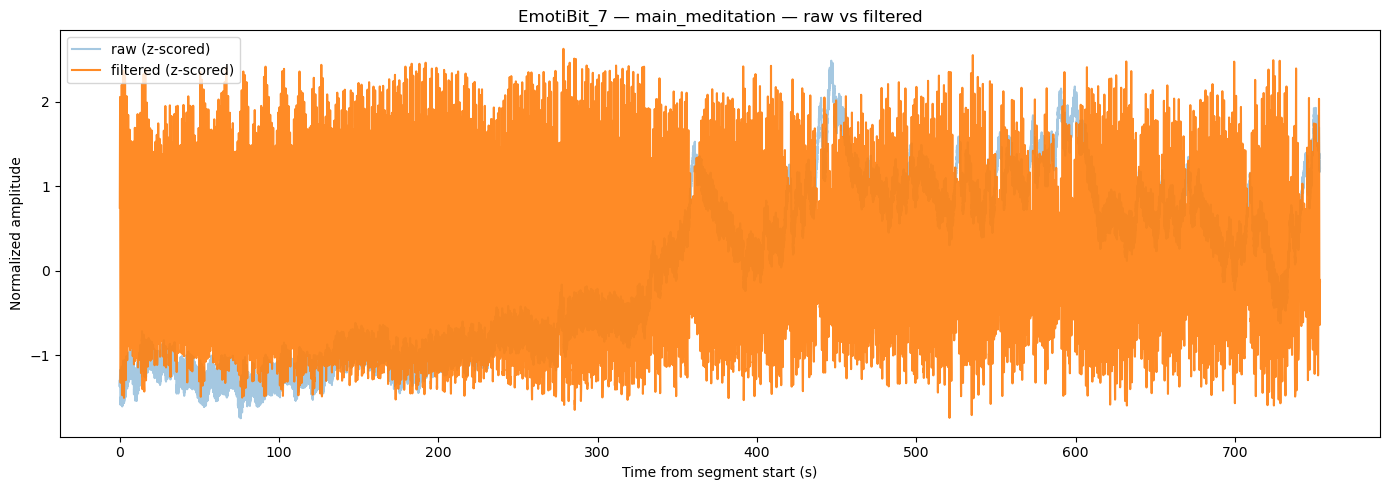

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_raw_vs_filtered.png


In [11]:
for emotibit_id in FINAL_CHANNEL_MAP.keys():
    path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_prepared.csv"
    if not path.exists():
        print("Missing:", path)
        continue

    df = pd.read_csv(path)

    t = df["time_from_segment_start_sec"].values
    raw_z = normalize_signal(df["selected_channel_raw"].values)
    filt_z = df["selected_channel_filtered_z"].values

    plt.figure(figsize=(14, 5))
    plt.plot(t, raw_z, label="raw (z-scored)", alpha=0.4)
    plt.plot(t, filt_z, label="filtered (z-scored)", alpha=0.9)
    plt.title(f"{emotibit_id} — main_meditation — raw vs filtered")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_raw_vs_filtered.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

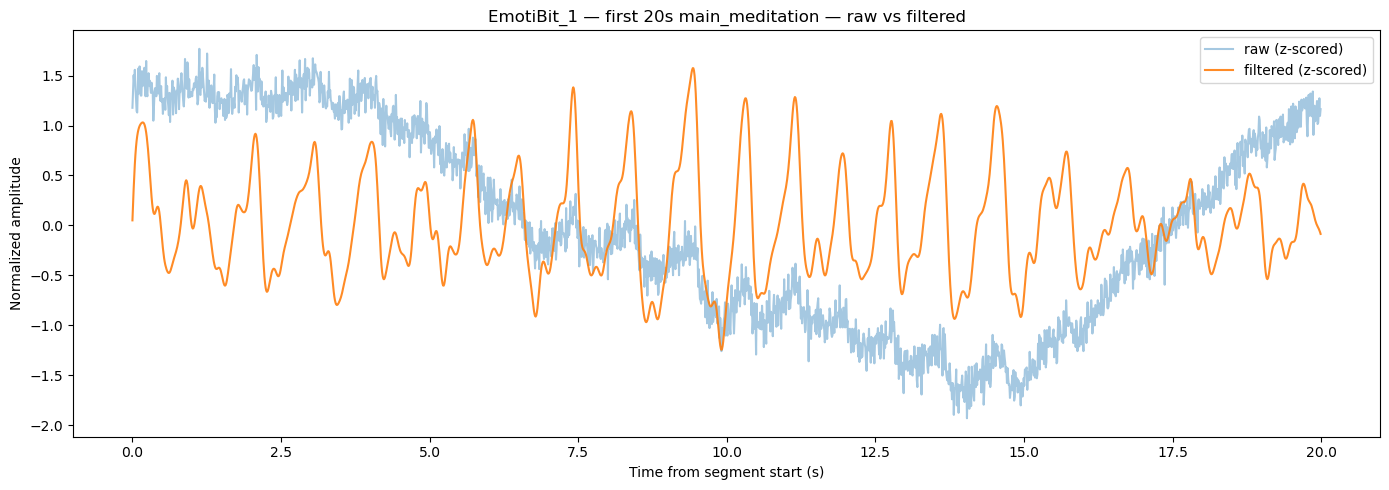

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_first20s_raw_vs_filtered.png


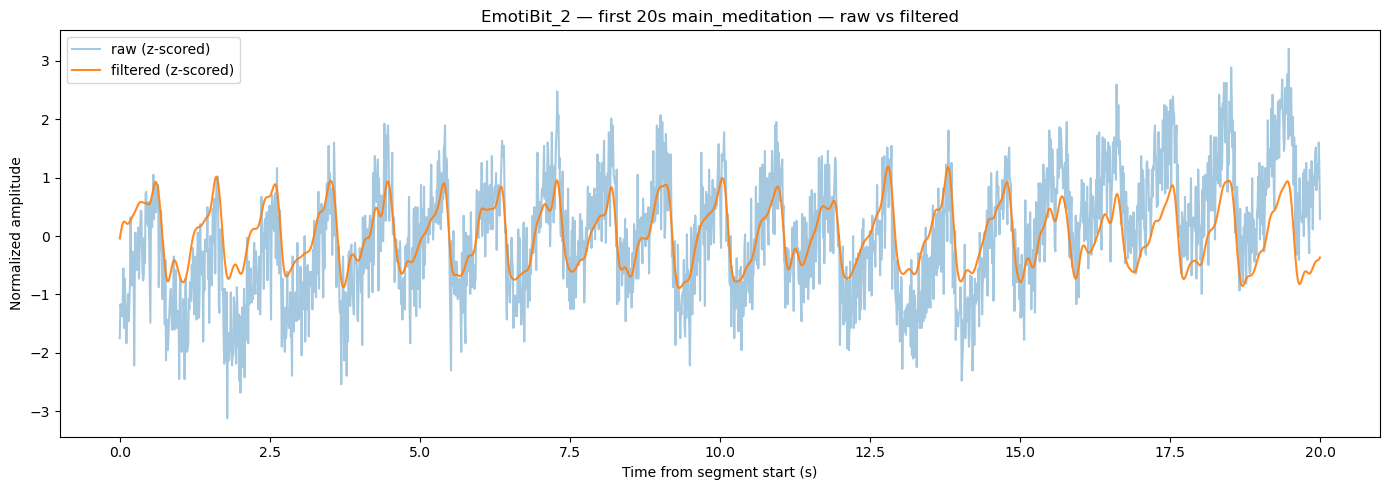

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_first20s_raw_vs_filtered.png


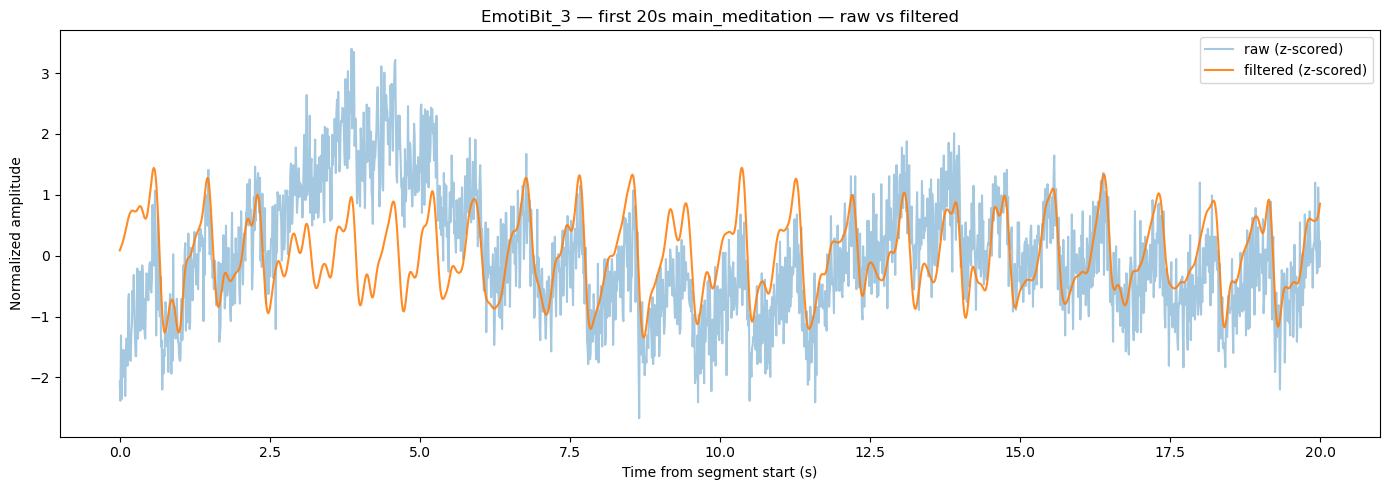

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_first20s_raw_vs_filtered.png


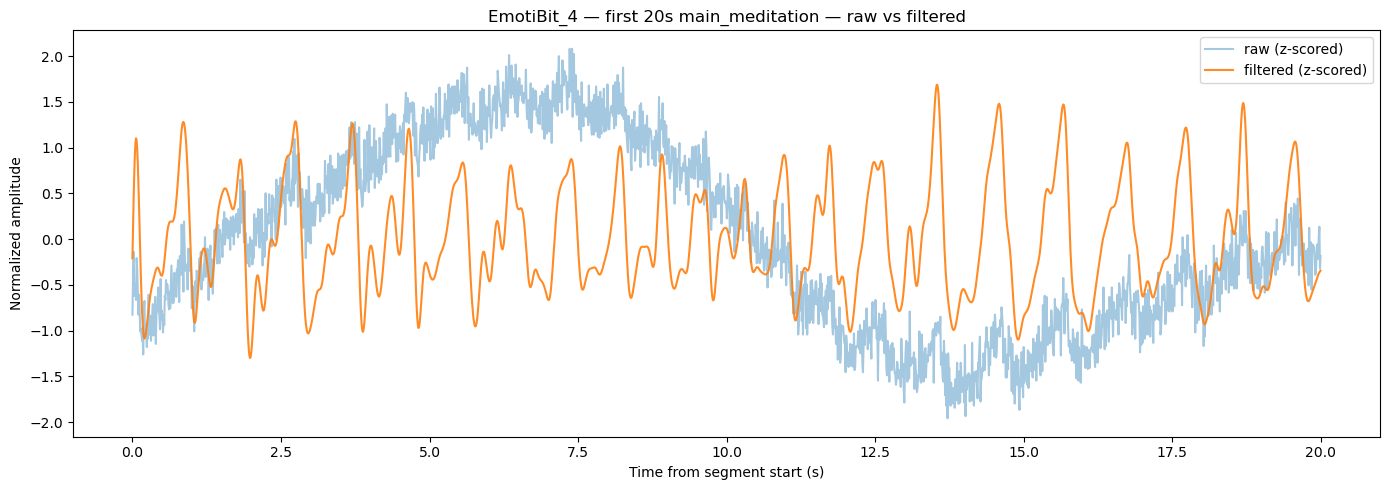

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_first20s_raw_vs_filtered.png


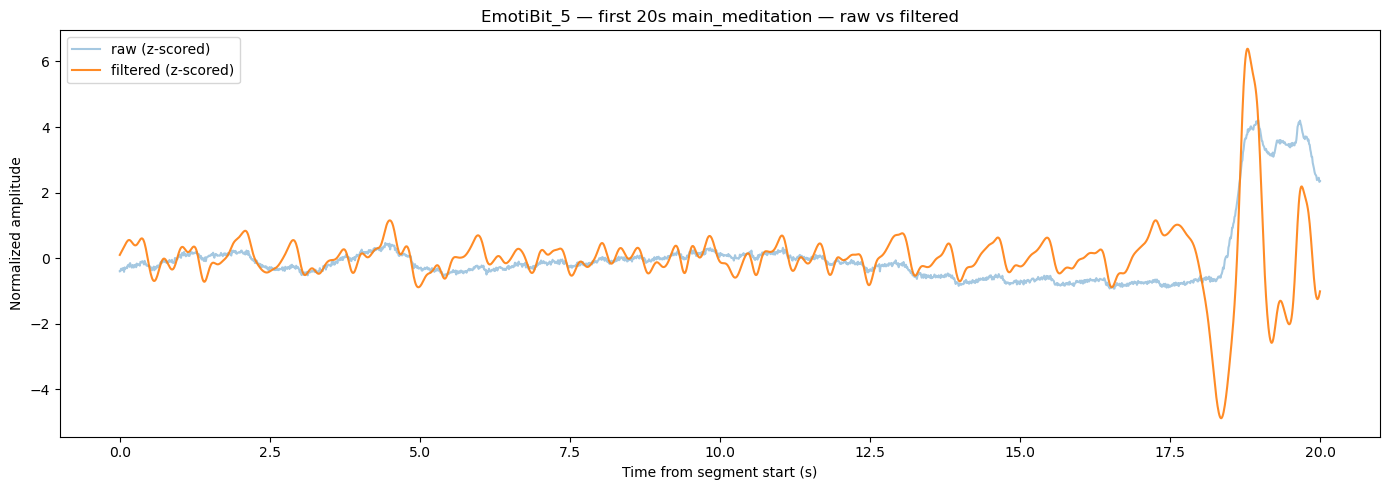

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_5_main_meditation_first20s_raw_vs_filtered.png


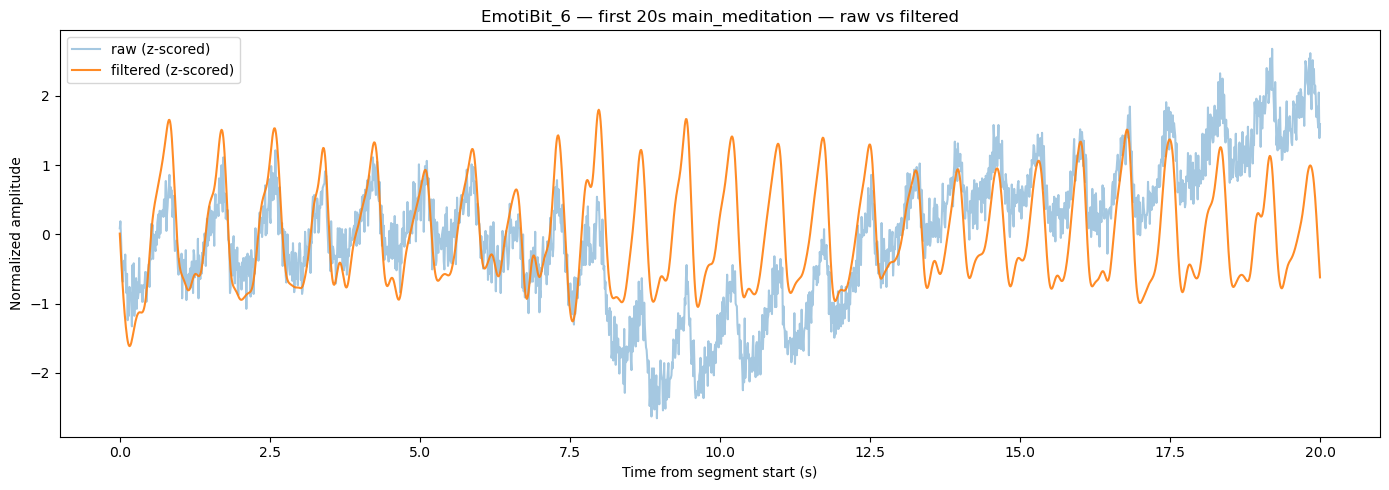

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_first20s_raw_vs_filtered.png


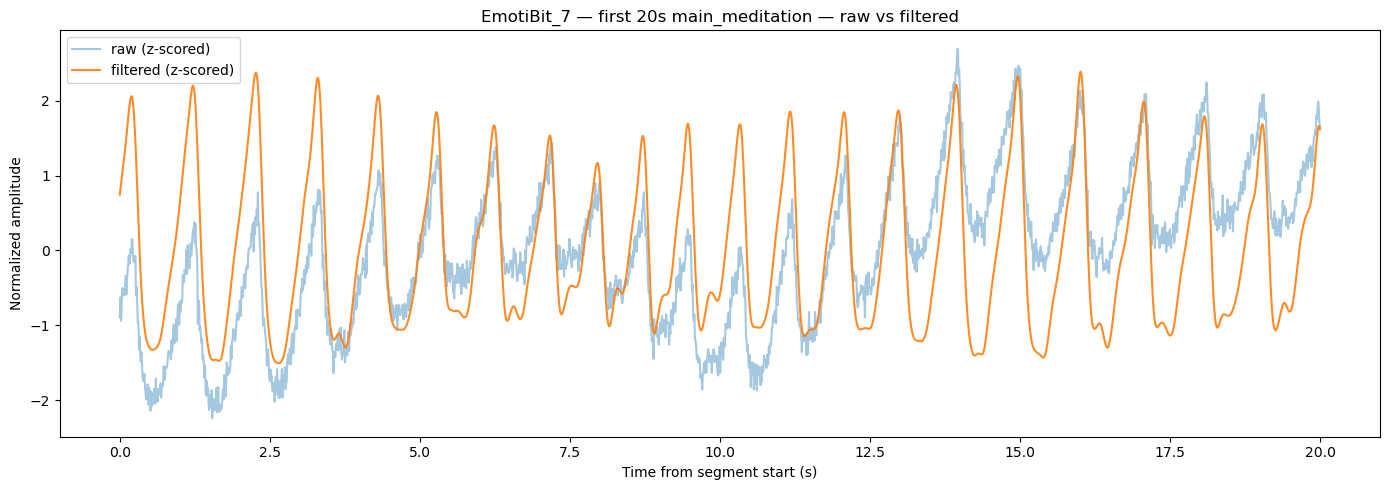

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_first20s_raw_vs_filtered.png


In [12]:
for emotibit_id in FINAL_CHANNEL_MAP.keys():
    path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_prepared.csv"
    if not path.exists():
        continue

    df = pd.read_csv(path)
    zoom_df = df[df["time_from_segment_start_sec"] <= 20].copy()

    if len(zoom_df) == 0:
        continue

    t = zoom_df["time_from_segment_start_sec"].values
    raw_z = normalize_signal(zoom_df["selected_channel_raw"].values)
    filt_z = zoom_df["selected_channel_filtered_z"].values

    plt.figure(figsize=(14, 5))
    plt.plot(t, raw_z, label="raw (z-scored)", alpha=0.4)
    plt.plot(t, filt_z, label="filtered (z-scored)", alpha=0.9)
    plt.title(f"{emotibit_id} — first 20s main_meditation — raw vs filtered")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_first20s_raw_vs_filtered.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [ ]:
print("=== PREPARE PPG FOR HR SUMMARY ===")
print("Used final validated channel map.")
print("Applied:")
print("1. robust outlier clipping")
print("2. linear detrending")
print("3. bandpass filtering (0.5–5.0 Hz)")
print("4. z-score normalization for visualization")
print()
print("Next notebook:")
print("06_peak_detection_and_hr_extraction.ipynb")

=== PREPARE PPG FOR HR SUMMARY ===
Used final validated channel map.
Applied:
1. robust outlier clipping
2. linear detrending
3. bandpass filtering (0.5–5.0 Hz)
4. z-score normalization for visualization

Next notebook:
05_peak_detection_and_hr_extraction.ipynb
